In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(r"C:\Users\DT1\Desktop\proj-python\Images_Vision")


# Harris Corner Detection

In [2]:
img=cv2.imread("chess_board.jpg")
img=cv2.resize(img,(512,512))
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray=np.float32(gray)
dst=cv2.cornerHarris(gray,2,3,0.06)
print(dst)
dst=cv2.dilate(dst,None)
img[dst>0.05*dst.max()]=[0,0,255]
cv2.imshow("img",img)
cv2.imshow("gray",gray)
cv2.imshow("dst",dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

[[       0.          0.          0.   ...        0.          0.
         0.  ]
 [       0.          0.          0.   ...        0.          0.
         0.  ]
 [       0.          0.    -247749.05 ...        0.          0.
         0.  ]
 ...
 [       0.          0.          0.   ... 49549816.   -4789814.
         0.  ]
 [       0.          0.          0.   ... -4789814.    -247749.05
         0.  ]
 [       0.          0.          0.   ...        0.          0.
         0.  ]]


# Fast Corner Detection

threshold 20
nonmaxSupression True
neighborhood 2
total keypoints 217


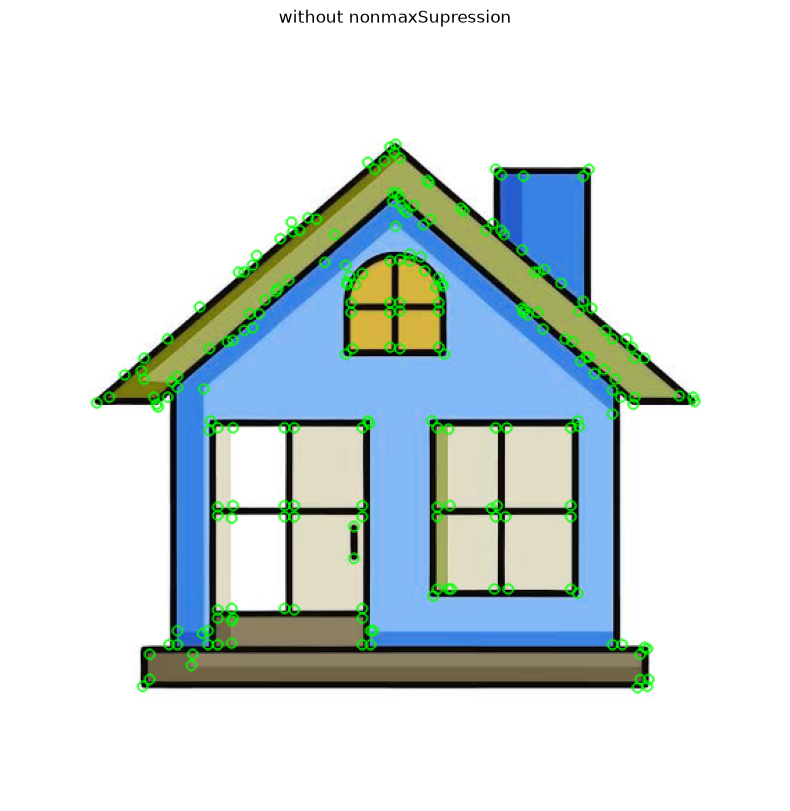

In [8]:
img=cv2.imread("home.jpg")
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
model = cv2.FastFeatureDetector_create(
    threshold=20,
    nonmaxSuppression=True,
    type=cv2.FAST_FEATURE_DETECTOR_TYPE_9_16
)
keypoints=model.detect(gray,None)
result=cv2.drawKeypoints(img,keypoints,None,(0,255,0),cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
print("threshold",model.getThreshold())
print("nonmaxSupression",model.getNonmaxSuppression())
print("neighborhood",model.getType())
print("total keypoints",len(keypoints))
plt.figure(figsize=(10,10))
plt.imshow(result)
plt.title("without nonmaxSupression")
plt.axis("off")
plt.show()
# cv2.imshow("img",img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

threshold 10
nonmaxSupression False
neighborhood 2
total keypoints 2383


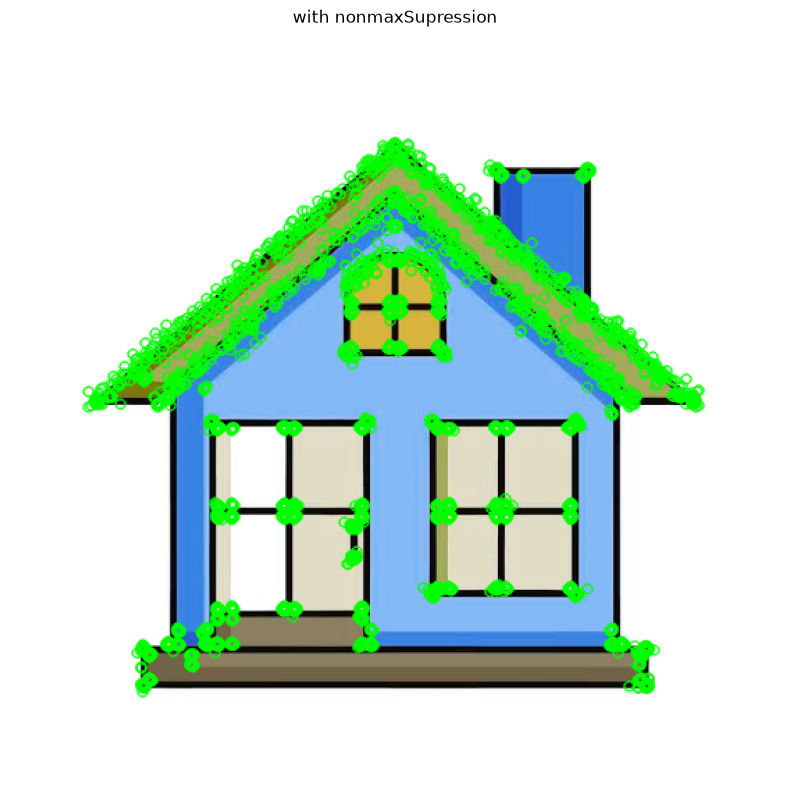

In [9]:
model.setNonmaxSuppression(0)
model.setThreshold(10)
model.setType(cv2.FAST_FEATURE_DETECTOR_TYPE_9_16)
keypoints=model.detect(gray,None)
result=cv2.drawKeypoints(img,keypoints,None,(0,255,0),cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
print("threshold",model.getThreshold())
print("nonmaxSupression",model.getNonmaxSuppression())
print("neighborhood",model.getType())
print("total keypoints",len(keypoints))
plt.figure(figsize=(10,10))
plt.imshow(result)
plt.title("with nonmaxSupression")
plt.axis("off")
plt.show()
# cv2.imshow("img",img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

# Blob Detection

keyPoints 14


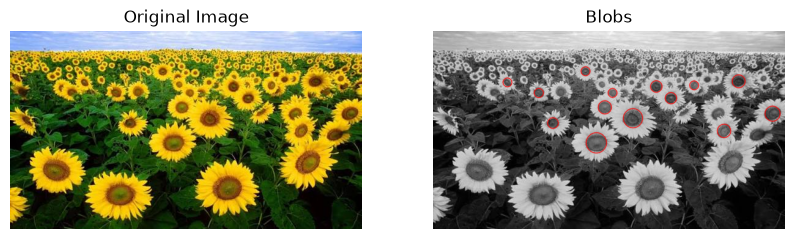

In [3]:
img=cv2.imread("abadElshams.jpg")
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(img)
plt.axis("off")
plt.title("Original Image")
# plt.show()

img=cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
# img=cv2.cvtColor(img,cv2.COLOR_RGB2BGR)

params=cv2.SimpleBlobDetector_Params()

params.minThreshold=20
params.thresholdStep=10
params.maxThreshold=220

params.filterByCircularity=True
params.minCircularity=0.6
params.maxCircularity=1

params.filterByConvexity=True
params.minConvexity=0.7
params.maxConvexity=1

params.filterByArea=True
params.minArea=150
params.maxArea=1000

params.filterByInertia = True
params.minInertiaRatio = 0.3
params.maxInertiaRatio = 1.0

params.filterByColor=True
params.blobColor=0

detector=cv2.SimpleBlobDetector_create(params)
keypoints=detector.detect(img)

print("keyPoints",len(keypoints))

img_blank=np.zeros((1,1))
img_keypoints=cv2.drawKeypoints(img,keypoints,None,(0,0,255),cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img_keypoints=cv2.cvtColor(img_keypoints,cv2.COLOR_BGR2RGB)
plt.subplot(1,2,2)
plt.imshow(img_keypoints)
plt.axis("off")
plt.title("Blobs")
plt.show()
# cv2.imshow("Blobs",img_keypoints)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
# cv2.imwrite("blobs.jpg",img_keypoints)

# SIFT Detection

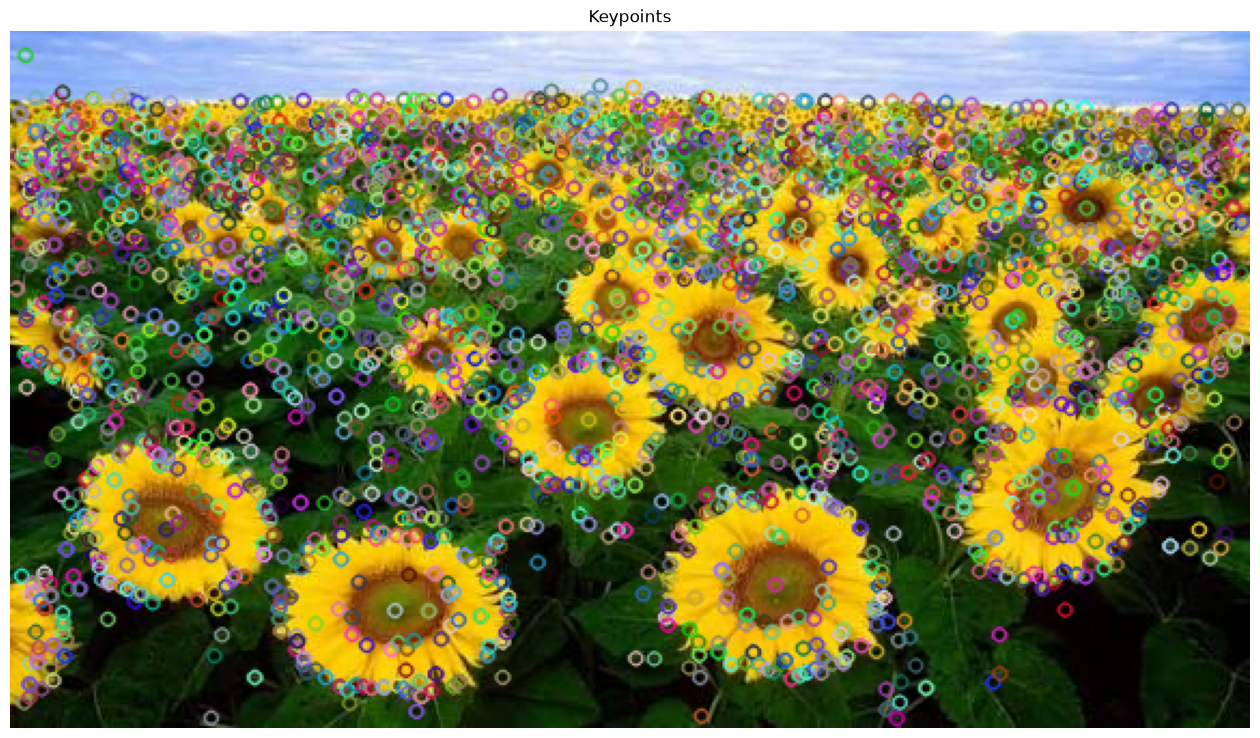

In [5]:
img=cv2.imread("abadElshams.jpg")
gray=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
model=cv2.SIFT_create()
keypoints=model.detect(gray)
result=cv2.drawKeypoints(gray,keypoints,None)
plt.figure(figsize=(16,16))
plt.imshow(result)
plt.axis("off")
plt.title("Keypoints")
plt.show()
# cv2.imshow("result",result)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

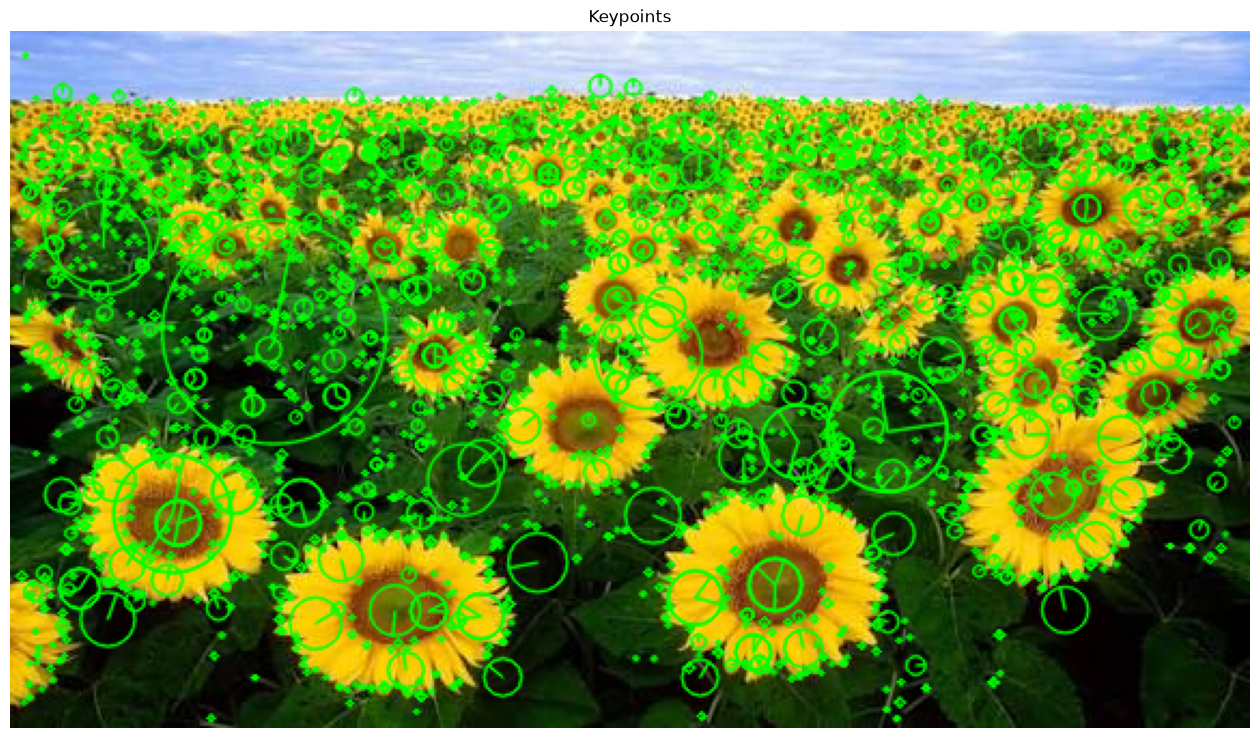

In [14]:
img=cv2.imread("abadElshams.jpg")
gray=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
model=cv2.SIFT_create()
keypoints=model.detect(gray)
result=cv2.drawKeypoints(gray,keypoints,None,(0,255,0),cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(16,16))
plt.imshow(result)
plt.axis("off")
plt.title("Keypoints")
plt.show()
# cv2.imshow("result",result)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

Number of keypoints: 2879
Description of keypoints: [[ 27.  60.   4. ...   0.   0.   0.]
 [  0.   0.   0. ... 115. 122.  18.]
 [ 23.  28. 108. ...   0.   0.   0.]
 ...
 [ 18.  14. 101. ...   0.   1.   0.]
 [ 43.  10.   2. ...   0.   0.   0.]
 [ 28.  29.  12. ...   0.   0.   0.]]


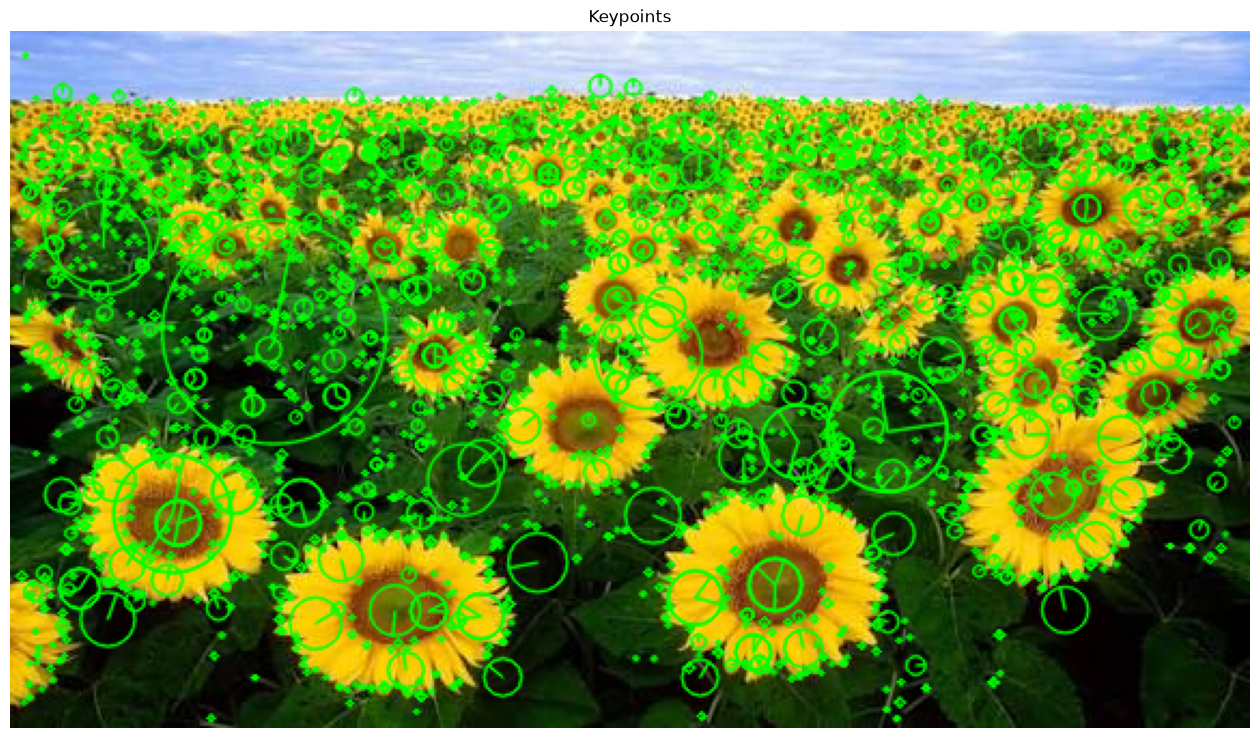

In [2]:
img=cv2.imread("abadElshams.jpg")
gray=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
model=cv2.SIFT_create()
keypoints,description=model.detectAndCompute(gray,None)
print(f"Number of keypoints: {len(keypoints)}")
print("Description of keypoints:",description)
result=cv2.drawKeypoints(gray,keypoints,None,(0,255,0),cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(16,16))
plt.imshow(result)
plt.axis("off")
plt.title("Keypoints")
plt.show()
# cv2.imshow("result",result)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

# Orinted Fast and Rotated BRIEF

In [ ]:
help(cv2.ORB_create().detectAndCompute)

Help on built-in function detectAndCompute:

detectAndCompute(...) method of cv2.ORB instance
    detectAndCompute(image, mask[, descriptors[, useProvidedKeypoints]]) -> keypoints, descriptors
    .   Detects keypoints and computes the descriptors



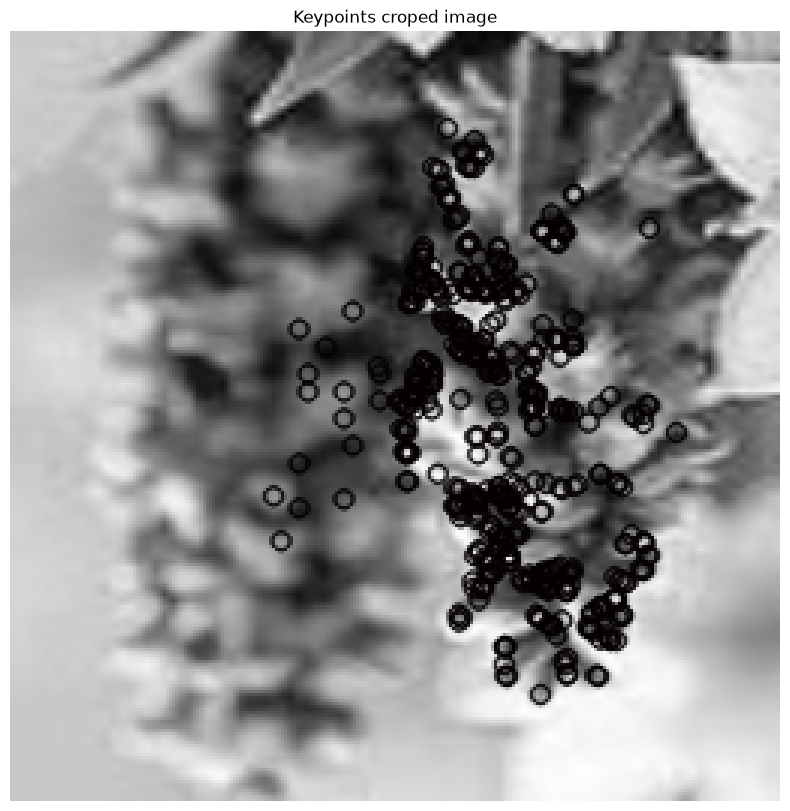

In [31]:
org_img=cv2.imread("image_3.jpg",0)
crop_img=cv2.imread("crop_image_3.jpg",0)
crop_img=cv2.resize(crop_img,(256,256))
model=cv2.ORB_create()
kp1,ds1=model.detectAndCompute(org_img,None)
kp2,ds2=model.detectAndCompute(crop_img,None)
img=cv2.drawKeypoints(crop_img,kp2,None,cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.title("Keypoints croped image")
plt.axis("off")
plt.show()

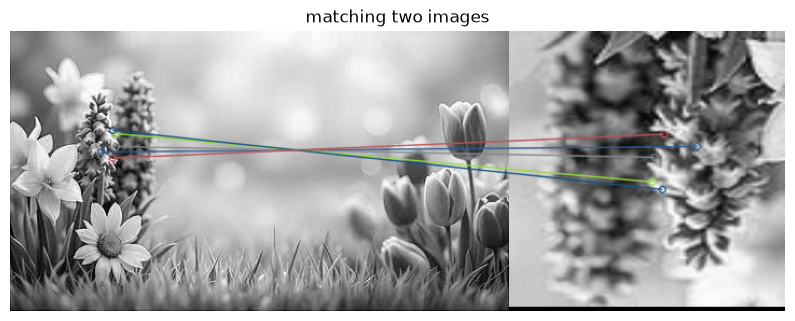

In [32]:
matcher=cv2.BFMatcher(cv2.NORM_HAMMING,crossCheck=True)
matches=matcher.match(ds1,ds2)
matches=sorted(matches,key=lambda x:x.distance)
img=cv2.drawMatches(org_img,kp1,crop_img,kp2,matches[:5],None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.title("matching two images")
plt.axis("off")
plt.show()